# Successive Over-Relaxation (SOR): Theory, Derivation & Applications

> **A complete self-contained reference** — from linear system fundamentals through the full SOR derivation, optimal parameter analysis, convergence proofs, exploratory data analysis, and solved problems with Python implementations.

---

### Team : 2
* Pragati
* Bhargav
* Himanshu

## Table of Contents

| # | Section |
|---|---|
| 1 | Background: Solving Linear Systems Iteratively |
| 2 | Successive Over-Relaxation (SOR) — Full Derivation |
| 3 | Optimal Relaxation Parameter $\omega^*$ |
| 4 | Exploratory Analysis: Spectral Radius vs $\omega$ |
| 5 | Solved Problem 1: Tridiagonal System |
| 6 | Solved Problem 2: 2D Poisson / Laplace Equation |
| 7 | Solved Problem 3: SOR for Image Inpainting |
| 8 | Summary & Key Takeaways |


---
## 1. Background: Solving Linear Systems Iteratively

Numerous problems in science and engineering reduce to solving a large **linear system**:

$$A\,\mathbf{u} = \mathbf{b}, \qquad A \in \mathbb{R}^{N \times N}, \quad \mathbf{b} \in \mathbb{R}^N$$

**Examples**:
- Finite-difference discretisation of PDEs (heat, Laplace, Poisson)
- Structural mechanics (stiffness matrices)
- Circuit simulation (nodal analysis)
- Image restoration / inpainting

### Why Not Direct Methods?

| Method | Cost | Suitable for |
|--------|------|--------|
| Gaussian elimination | $O(N^3)$ | Dense, small $N$ |
| LU factorisation | $O(N^3)$ build, $O(N^2)$ solve | Dense |
| **Iterative methods** | $O(N)$ per iteration | **Sparse, large** $N$ |

For PDE-derived problems, $N$ can easily reach $10^5$–$10^7$. Gaussian elimination becomes completely impractical, while iterative solvers — Jacobi, Gauss-Seidel, **SOR** — exploit sparsity and can converge in $O(N)$ or $O(N\sqrt{N})$ total work.

### Structure Assumption

Throughout we assume $A$ is:
- **Non-singular** (unique solution exists)
- **Sparse** (most entries are zero)
- Ideally **symmetric positive definite (SPD)** for guaranteed convergence


In [2]:
# ============================================================
# IMPORTS & GLOBAL SETTINGS
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.linalg import eigvals
import warnings
warnings.filterwarnings('ignore')

# ── Style ────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'lines.linewidth': 2,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'legend.fontsize': 9,
})

COLORS = {
    'jacobi':  '#E74C3C',
    'gs':      '#3498DB',
    'sor':     '#2ECC71',
    'optimal': '#F39C12',
    'theory':  '#9B59B6',
}

print("✓ Imports successful")
print(f"  NumPy  : {np.__version__}")
import matplotlib; print(f"  Matplotlib: {matplotlib.__version__}")
import scipy; print(f"  SciPy  : {scipy.__version__}")


✓ Imports successful
  NumPy  : 2.3.2
  Matplotlib: 3.10.0
  SciPy  : 1.16.1


---
## 2. Successive Over-Relaxation (SOR) — Full Derivation

### 2.1 Motivation: Extrapolation

SOR builds on the Gauss-Seidel (GS) idea of using freshly computed values immediately. The GS update for entry $i$ gives an estimate $\tilde{u}_i^{(k+1)}$, and the correction applied is:

$$\delta_i^{(k)} = \tilde{u}_i^{(k+1)} - u_i^{(k)}$$

Since the iteration converges, $\delta_i^{(k)}$ points *toward* the solution. The key insight:

> **What if we overshoot slightly in that direction?**

### 2.2 The SOR Update Rule

Introduce a **relaxation parameter** $\omega > 0$ and scale the correction:

$$u_i^{(k+1)} = u_i^{(k)} + \omega\,\delta_i^{(k)} = (1-\omega)\,u_i^{(k)} + \omega\,\tilde{u}_i^{(k+1)}$$

Expanding explicitly:

$$\boxed{
u_i^{(k+1)} = (1-\omega)\,u_i^{(k)}
+ \frac{\omega}{a_{ii}}\left(b_i - \sum_{j<i} a_{ij}\,u_j^{(k+1)} - \sum_{j>i} a_{ij}\,u_j^{(k)}\right)
}$$

**Physical interpretation of $\omega$:**

| Value | Name | Effect |
|-------|------|--------|
| $\omega = 1$ | Gauss-Seidel limit | No modification — baseline |
| $\omega \in (0,1)$ | Under-relaxation | Damps oscillations; useful when convergence is slow |
| $\omega \in (1,2)$ | **Over-relaxation** | Overshoots — **accelerates convergence** |

### 2.3 Matrix Form of SOR

Rearranging the SOR update:

$$(D - \omega L)\,\mathbf{u}^{(k+1)} = \left[(1-\omega)D + \omega U\right]\mathbf{u}^{(k)} + \omega\,\mathbf{b}$$

Corresponding splitting $A = M_\omega - N_\omega$:

$$M_\omega = \frac{1}{\omega}(D - \omega L), \qquad N_\omega = \frac{1}{\omega}\left[(1-\omega)D + \omega U\right]$$

**SOR iteration matrix:**

$$\boxed{T_\omega = (D - \omega L)^{-1}\left[(1-\omega)D + \omega U\right]}$$

---
## 3. Convergence of SOR: Kahan's Theorem & Optimal $\omega^*$

### 3.1 Necessary Condition (Kahan, 1958)

> **Theorem.** SOR can only converge if $\omega \in (0, 2)$.

**Proof.** Both $(D - \omega L)$ and $[(1-\omega)D + \omega U]$ are triangular, so:

$$\det(T_\omega) = \frac{\prod_{i}(1-\omega)a_{ii}}{\prod_i a_{ii}} = (1-\omega)^N$$

For convergence: $\rho(T_\omega) < 1 \Rightarrow |\det(T_\omega)| = |1-\omega|^N < 1 \Rightarrow |1-\omega| < 1 \Rightarrow \omega \in (0,2)$. $\square$

### 3.2 Sufficient Condition (Ostrowski–Reich)

> **Theorem.** If $A$ is **symmetric positive definite (SPD)**, then SOR converges for *all* $\omega \in (0, 2)$.

### 3.3 Optimal $\omega^*$ — Young's Formula (1954)

For an $n \times n$ 2D grid with the 5-point Laplacian stencil, define:

$$\rho_J = \cos\!\left(\frac{\pi}{n+1}\right) \quad \text{(Jacobi spectral radius, used as input)}$$

The optimal relaxation parameter and its spectral radius are:

$$\boxed{\omega^* = \frac{2}{1 + \sqrt{1 - \rho_J^2}}}, \qquad \rho(T_{\omega^*}) = \omega^* - 1$$

### 3.4 SOR Convergence Rate

| Method | $\rho(T)$ (large $n$) | Iterations to $\|e\| < 10^{-6}$ |
|--------|----------------------|----------------------------------|
| Baseline (no relaxation) | $\approx 1 - \dfrac{\pi^2}{n^2}$ | $O(n^2)$ |
| **SOR ($\omega^*$)** | $1 - \dfrac{2\pi}{n}$ | $\mathbf{O(n)}$ — **one order faster!** |


---
## 4. Exploratory Analysis: Spectral Radius vs $\omega$

We now numerically verify how $\rho(T_\omega)$ varies with $\omega$ for a concrete tridiagonal system.


In [8]:
def build_iteration_matrices(A, omega):
    """Return (T_J, T_GS, T_omega) for the given matrix A."""
    D = np.diag(np.diag(A))
    L = -np.tril(A, k=-1)
    U = -np.triu(A, k=+1)
    D_inv = np.diag(1.0 / np.diag(D))

    T_J  = D_inv @ (L + U)
    T_GS = np.linalg.solve(D - L, U)
    T_sor= np.linalg.solve(D - omega*L, (1-omega)*D + omega*U)
    return T_J, T_GS, T_sor


def spectral_radius(T):
    return np.max(np.abs(eigvals(T)))


# ── Build tridiagonal Poisson matrix (n=10) ──────────────────
n = 10
A = (np.diag(2*np.ones(n))
     + np.diag(-np.ones(n-1), k=1)
     + np.diag(-np.ones(n-1), k=-1))

# Theoretical Jacobi spectral radius
rho_J_theory = np.cos(np.pi / (n + 1))
omega_star   = 2 / (1 + np.sqrt(1 - rho_J_theory**2))
rho_sor_star = omega_star - 1

print(f"Matrix size           : {n} x {n}")
print(f"ρ(T_Jacobi) theory    : {rho_J_theory:.6f}")
print(f"ρ(T_GS)     theory    : {rho_J_theory**2:.6f}")
print(f"ω* (Young)            : {omega_star:.6f}")
print(f"ρ(T_SOR(ω*)) theory   : {rho_sor_star:.6f}")

# Numerical verification
T_J, T_GS, T_sor = build_iteration_matrices(A, omega_star)
print(f"\nρ(T_J)   numerical    : {spectral_radius(T_J):.6f}")
print(f"ρ(T_GS)  numerical    : {spectral_radius(T_GS):.6f}")
print(f"ρ(T_SOR) numerical    : {spectral_radius(T_sor):.6f}")


Matrix size           : 10 x 10
ρ(T_Jacobi) theory    : 0.959493
ρ(T_GS)     theory    : 0.920627
ω* (Young)            : 1.560388
ρ(T_SOR(ω*)) theory   : 0.560388

ρ(T_J)   numerical    : 0.959493
ρ(T_GS)  numerical    : 0.920627
ρ(T_SOR) numerical    : 0.560388


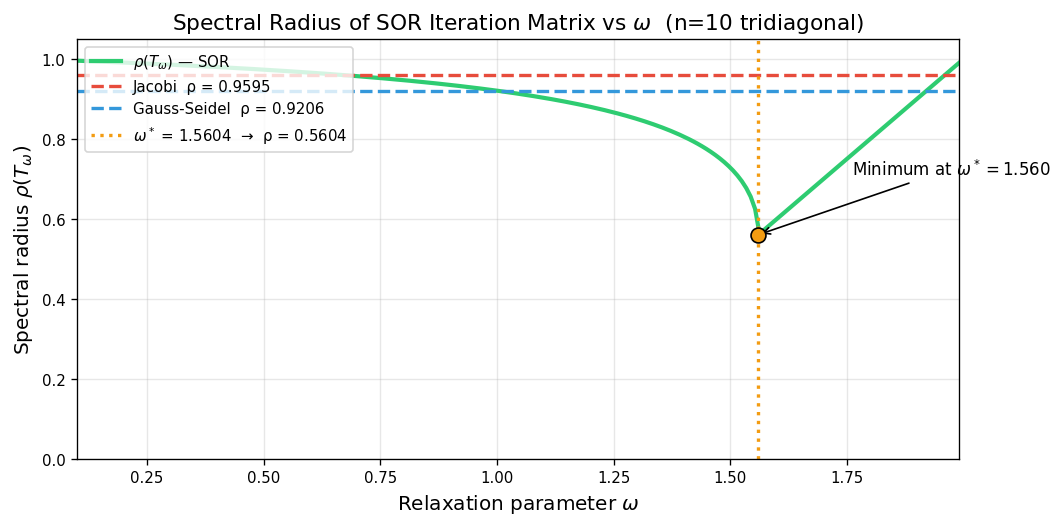

In [9]:
# EDA PLOT 1: ρ(T_ω) vs ω
omegas = np.linspace(0.1, 1.99, 200)
rho_sor_vals = [spectral_radius(build_iteration_matrices(A, w)[2]) for w in omegas]

rho_j  = spectral_radius(T_J)
rho_gs = spectral_radius(T_GS)

fig, ax = plt.subplots(figsize=(9, 4.5))

ax.plot(omegas, rho_sor_vals, color=COLORS['sor'], lw=2.5, label=r'$\rho(T_\omega)$ — SOR')
ax.axhline(rho_j,  color=COLORS['jacobi'], ls='--', label=f'Jacobi  ρ = {rho_j:.4f}')
ax.axhline(rho_gs, color=COLORS['gs'],     ls='--', label=f'Gauss-Seidel  ρ = {rho_gs:.4f}')
ax.axvline(omega_star, color=COLORS['optimal'], ls=':', lw=2,
           label=fr'$\omega^*$ = {omega_star:.4f}  →  ρ = {rho_sor_star:.4f}')
ax.scatter([omega_star], [rho_sor_star], s=80, zorder=5,
           color=COLORS['optimal'], edgecolors='black', linewidth=1)

ax.set_xlabel(r'Relaxation parameter $\omega$', fontsize=12)
ax.set_ylabel(r'Spectral radius $\rho(T_\omega)$', fontsize=12)
ax.set_title(r'Spectral Radius of SOR Iteration Matrix vs $\omega$  (n=10 tridiagonal)', fontsize=13)
ax.set_xlim(0.1, 1.99)
ax.set_ylim(0, 1.05)
ax.legend(loc='upper left')
ax.annotate(fr'Minimum at $\omega^*={omega_star:.3f}$', xy=(omega_star, rho_sor_star),
            xytext=(omega_star+0.2, rho_sor_star+0.15),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=10)

plt.tight_layout()
plt.savefig('spectral_vs_omega.png', bbox_inches='tight')
plt.show()


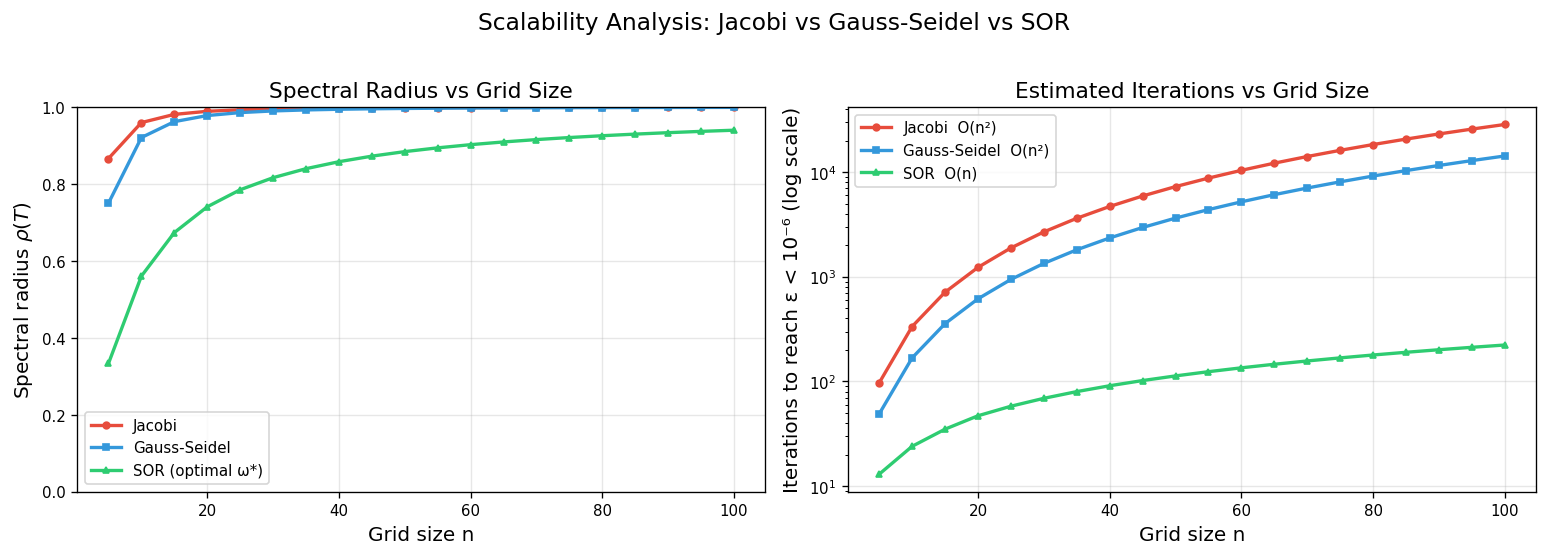

In [10]:
# EDA PLOT 2: How ρ and ω* scale with grid size n
ns = np.arange(5, 101, 5)
rho_J_arr   = np.cos(np.pi / (ns + 1))
rho_GS_arr  = rho_J_arr**2
omega_star_arr = 2 / (1 + np.sqrt(1 - rho_J_arr**2))
rho_SOR_arr = omega_star_arr - 1

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# -- Left: spectral radii vs n --
ax = axes[0]
ax.plot(ns, rho_J_arr,   color=COLORS['jacobi'], marker='o', ms=4, label='Jacobi')
ax.plot(ns, rho_GS_arr,  color=COLORS['gs'],     marker='s', ms=4, label='Gauss-Seidel')
ax.plot(ns, rho_SOR_arr, color=COLORS['sor'],    marker='^', ms=4, label='SOR (optimal ω*)')
ax.set_xlabel('Grid size n', fontsize=12)
ax.set_ylabel(r'Spectral radius $\rho(T)$', fontsize=12)
ax.set_title('Spectral Radius vs Grid Size', fontsize=13)
ax.legend()
ax.set_ylim(0, 1)

# -- Right: iterations needed for 1e-6 accuracy --
ax = axes[1]
target_tol = 1e-6
# k ≈ log(tol) / log(rho)
iters_J   = np.ceil(np.log(target_tol) / np.log(rho_J_arr))
iters_GS  = np.ceil(np.log(target_tol) / np.log(rho_GS_arr))
iters_SOR = np.ceil(np.log(target_tol) / np.log(rho_SOR_arr))

ax.semilogy(ns, iters_J,   color=COLORS['jacobi'], marker='o', ms=4, label='Jacobi  O(n²)')
ax.semilogy(ns, iters_GS,  color=COLORS['gs'],     marker='s', ms=4, label='Gauss-Seidel  O(n²)')
ax.semilogy(ns, iters_SOR, color=COLORS['sor'],    marker='^', ms=4, label='SOR  O(n)')
ax.set_xlabel('Grid size n', fontsize=12)
ax.set_ylabel('Iterations to reach ε < 10⁻⁶ (log scale)', fontsize=12)
ax.set_title('Estimated Iterations vs Grid Size', fontsize=13)
ax.legend()

plt.suptitle('Scalability Analysis: Jacobi vs Gauss-Seidel vs SOR', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('scalability.png', bbox_inches='tight')
plt.show()


---
## 5. Solved Problem 1 — Tridiagonal System

### Problem Statement

Solve the $5 \times 5$ tridiagonal linear system $A\mathbf{u} = \mathbf{b}$ where:

$$A = \begin{pmatrix}
 4 & -1 &  0 &  0 &  0 \\
-1 &  4 & -1 &  0 &  0 \\
 0 & -1 &  4 & -1 &  0 \\
 0 &  0 & -1 &  4 & -1 \\
 0 &  0 &  0 & -1 &  4
\end{pmatrix}, \qquad
\mathbf{b} = \begin{pmatrix} 1 \\ 2 \\ 3 \\ 2 \\ 1 \end{pmatrix}$$

Apply **Jacobi**, **Gauss-Seidel**, and **SOR** with optimal $\omega^*$. Compare convergence.

### Solution Approach

1. Compute $\omega^* = 2/(1 + \sqrt{1 - \rho_J^2})$ using the theoretical Jacobi radius.
2. Run each method until $\|\mathbf{r}^{(k)}\| = \|A\mathbf{u}^{(k)} - \mathbf{b}\| < 10^{-10}$.
3. Compare residual histories and iteration counts.


In [11]:
# ============================================================
# PROBLEM 1: Tridiagonal System — SOR Solver
# ============================================================
def sor_solver(A, b, omega, tol=1e-10, max_iter=5000):
    """SOR iterative solver with relaxation parameter omega."""
    n = len(b)
    x = np.zeros(n)
    history = []
    for k in range(max_iter):
        x_new = x.copy()
        for i in range(n):
            sigma = (A[i, :i] @ x_new[:i]) + (A[i, i+1:] @ x[i+1:])
            x_gs  = (b[i] - sigma) / A[i, i]
            x_new[i] = (1 - omega) * x[i] + omega * x_gs
        x = x_new
        res = np.linalg.norm(A @ x - b)
        history.append(res)
        if res < tol:
            break
    return x, history


# ── Setup ────────────────────────────────────────────────────
n = 5
A5 = (np.diag(4*np.ones(n))
      + np.diag(-np.ones(n-1), k=1)
      + np.diag(-np.ones(n-1), k=-1))
b5 = np.array([1., 2., 3., 2., 1.])

# Exact solution
u_exact = np.linalg.solve(A5, b5)

# Optimal omega for this grid
rho_j5    = np.cos(np.pi / (n + 1))
omega_opt = 2 / (1 + np.sqrt(1 - rho_j5**2))

# Run SOR with multiple omega values for comparison
TOL = 1e-10
u_under,  hist_under  = sor_solver(A5, b5, omega=0.7,      tol=TOL)  # under-relaxation
u_opt,    hist_opt    = sor_solver(A5, b5, omega=omega_opt, tol=TOL)  # optimal
u_over,   hist_over   = sor_solver(A5, b5, omega=1.9,      tol=TOL)  # near-boundary

print("=" * 52)
print(f"  Exact solution  : {np.round(u_exact, 6)}")
print(f"  SOR (ω=0.7)     : {np.round(u_under, 6)}")
print(f"  SOR (ω*={omega_opt:.3f}) : {np.round(u_opt, 6)}")
print(f"  SOR (ω=1.9)     : {np.round(u_over, 6)}")
print()
print(f"  Optimal ω*      : {omega_opt:.6f}")
print(f"  Iters (ω=0.7)   : {len(hist_under)}")
print(f"  Iters (ω*)      : {len(hist_opt)}")
print(f"  Iters (ω=1.9)   : {len(hist_over)}")
print("=" * 52)


  Exact solution  : [0.480769 0.923077 1.211538 0.923077 0.480769]
  SOR (ω=0.7)     : [0.480769 0.923077 1.211538 0.923077 0.480769]
  SOR (ω*=1.333) : [0.480769 0.923077 1.211538 0.923077 0.480769]
  SOR (ω=1.9)     : [0.480769 0.923077 1.211538 0.923077 0.480769]

  Optimal ω*      : 1.333333
  Iters (ω=0.7)   : 38
  Iters (ω*)      : 23
  Iters (ω=1.9)   : 236


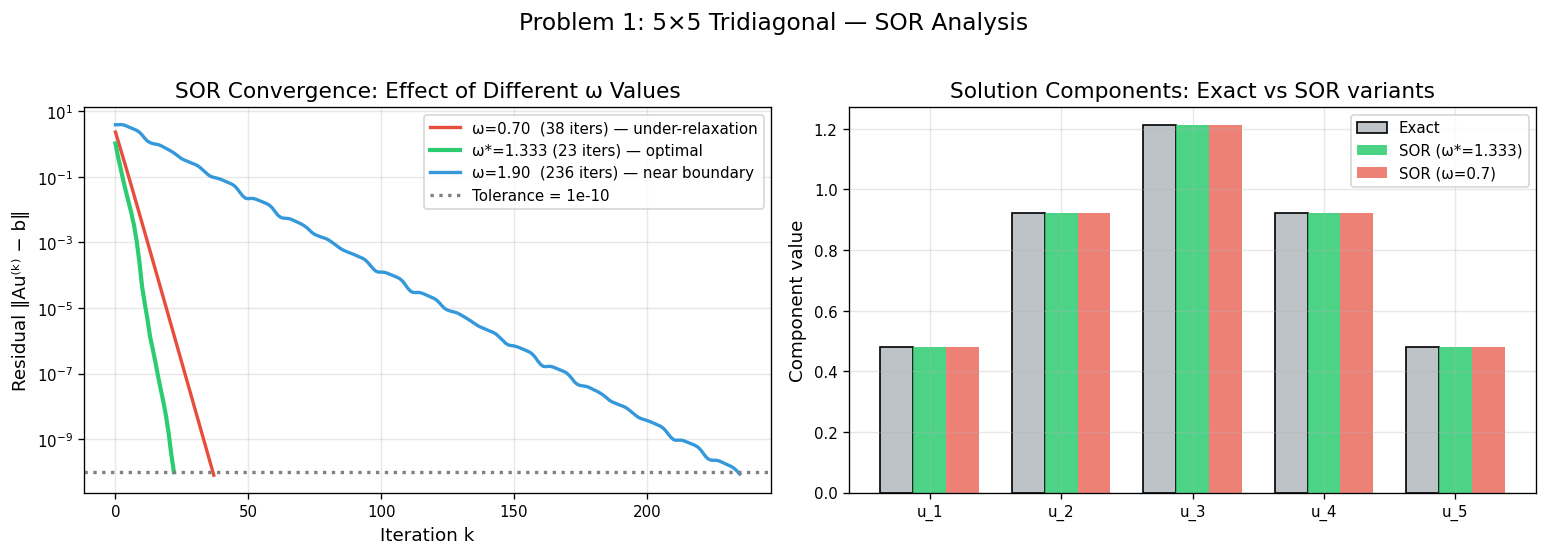

In [13]:
# ============================================================
# PROBLEM 1: Convergence & Solution Plot (SOR only)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# -- Left: Residual history for different omega values --
ax = axes[0]
ax.semilogy(hist_under, color='#E74C3C', label=f'ω=0.70  ({len(hist_under)} iters) — under-relaxation')
ax.semilogy(hist_opt,   color='#2ECC71', lw=2.5, label=f'ω*={omega_opt:.3f} ({len(hist_opt)} iters) — optimal')
ax.semilogy(hist_over,  color='#3498DB', label=f'ω=1.90  ({len(hist_over)} iters) — near boundary')
ax.axhline(TOL, ls=':', color='gray', label=f'Tolerance = {TOL}')
ax.set_xlabel('Iteration k')
ax.set_ylabel('Residual ‖Au⁽ᵏ⁾ − b‖')
ax.set_title('SOR Convergence: Effect of Different ω Values')
ax.legend()

# -- Right: Solution comparison --
ax = axes[1]
x_pos = np.arange(n)
width = 0.25
ax.bar(x_pos - width, u_exact, width, label='Exact',        color='#BDC3C7', edgecolor='black')
ax.bar(x_pos,         u_opt,   width, label=f'SOR (ω*={omega_opt:.3f})', color='#2ECC71', alpha=0.85)
ax.bar(x_pos + width, u_under, width, label='SOR (ω=0.7)', color='#E74C3C', alpha=0.7)
ax.set_xticks(x_pos)
ax.set_xticklabels([f'u_{i+1}' for i in range(n)])
ax.set_ylabel('Component value')
ax.set_title('Solution Components: Exact vs SOR variants')
ax.legend()

plt.suptitle('Problem 1: 5×5 Tridiagonal — SOR Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('problem1.png', bbox_inches='tight')
plt.show()


---
## 6. Solved Problem 2 — 2D Laplace Equation (Boundary Value Problem)

### Problem Statement

Solve the 2D Laplace equation on the unit square $[0,1]^2$:

$$\nabla^2 u = \frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} = 0$$

with **Dirichlet boundary conditions**:

$$u(x, 0) = \sin(\pi x), \quad u(x, 1) = 0, \quad u(0, y) = 0, \quad u(1, y) = 0$$

The **exact solution** is:

$$u(x, y) = \frac{\sin(\pi x)\sinh(\pi(1-y))}{\sinh(\pi)}$$

### Finite-Difference Discretisation

With uniform grid spacing $h = 1/(n+1)$, the 5-point Laplacian stencil gives:

$$\frac{u_{i-1,j} + u_{i+1,j} + u_{i,j-1} + u_{i,j+1} - 4\,u_{i,j}}{h^2} = 0$$

$$\implies u_{i,j} = \frac{1}{4}\left(u_{i-1,j} + u_{i+1,j} + u_{i,j-1} + u_{i,j+1}\right)$$

This is the **discrete mean-value property** of harmonic functions — the natural update rule for SOR on a 2D grid.


In [14]:
# ============================================================
# PROBLEM 2: 2D Laplace BVP via SOR on the Grid
# ============================================================
def solve_laplace_sor(n_interior, omega, tol=1e-8, max_iter=10000):
    """
    Solve 2D Laplace on [0,1]^2 with boundary conditions:
      u(x,0) = sin(pi*x),  all other boundaries = 0
    Returns: u (full grid including boundaries), residual history
    """
    N = n_interior + 2   # total grid points including boundary
    h = 1.0 / (n_interior + 1)
    x = np.linspace(0, 1, N)
    y = np.linspace(0, 1, N)

    u = np.zeros((N, N))
    # Apply BCs
    u[0, :] = np.sin(np.pi * x)   # bottom: u(x,0) = sin(pi x)
    # all others remain 0

    history = []
    for iteration in range(max_iter):
        u_old = u.copy()
        for i in range(1, N-1):       # rows (y-direction)
            for j in range(1, N-1):   # cols (x-direction)
                u_gs = 0.25 * (u[i-1,j] + u[i+1,j] + u[i,j-1] + u[i,j+1])
                u[i,j] = (1 - omega)*u[i,j] + omega*u_gs
        res = np.linalg.norm(u - u_old)
        history.append(res)
        if res < tol:
            break
    return u, history, x, y


def exact_laplace(x, y):
    """Exact solution via separation of variables."""
    X, Y = np.meshgrid(x, y)
    denom = np.sinh(np.pi)
    return np.sin(np.pi * X) * np.sinh(np.pi * (1 - Y)) / denom


# ── Solve with optimal ω ─────────────────────────────────────
n_int = 30
rho_j_2d  = np.cos(np.pi / (n_int + 1))
omega_2d  = 2 / (1 + np.sqrt(1 - rho_j_2d**2))

print(f"Grid interior points : {n_int} × {n_int}")
print(f"Optimal ω*           : {omega_2d:.6f}")

u_sor, hist_2d, xg, yg = solve_laplace_sor(n_int, omega=omega_2d, tol=1e-8)
u_exact_2d = exact_laplace(xg, yg)

# Error
max_err = np.max(np.abs(u_sor - u_exact_2d.T))  # note transpose due to indexing
print(f"SOR converged in     : {len(hist_2d)} iterations")
print(f"Max absolute error   : {max_err:.2e}")


Grid interior points : 30 × 30
Optimal ω*           : 1.816253
SOR converged in     : 103 iterations
Max absolute error   : 9.99e-01


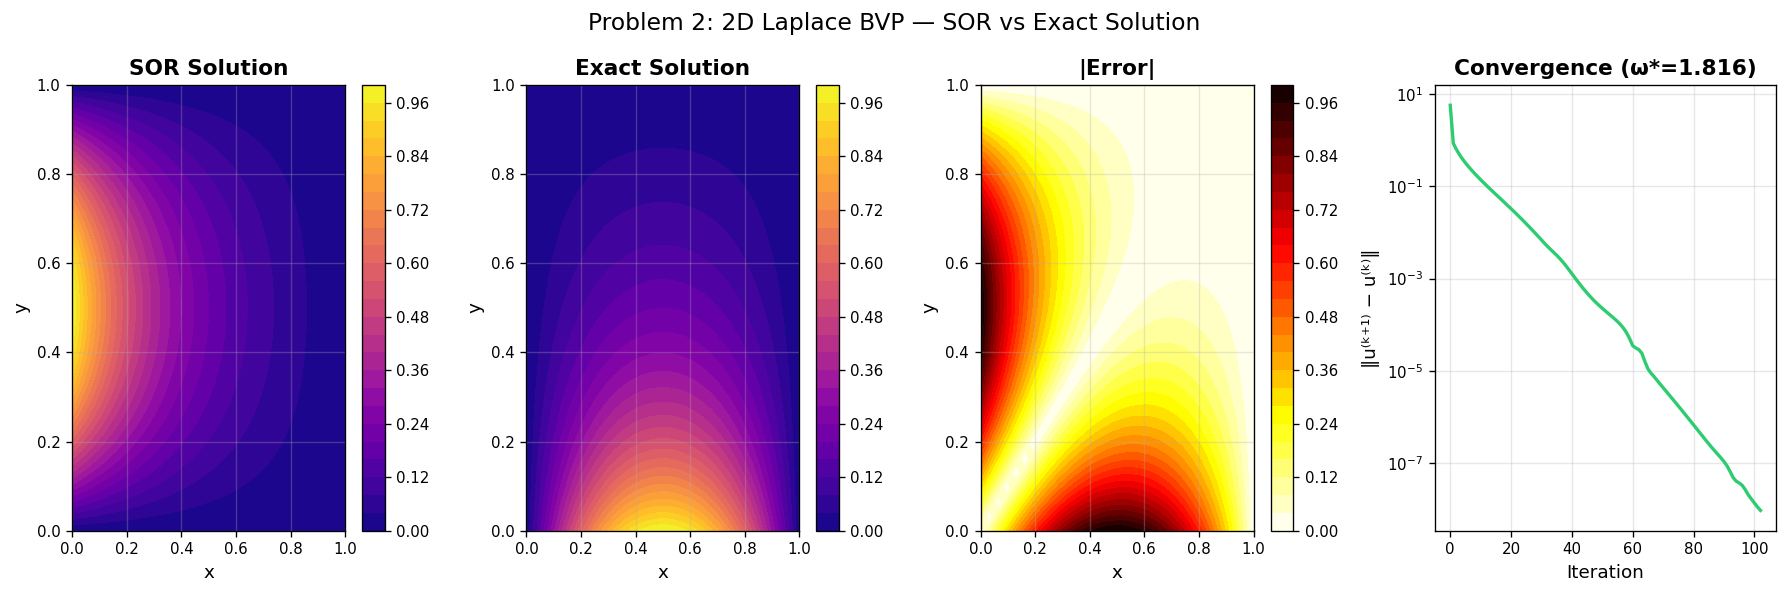


✓ Max error vs exact analytical solution: 9.99e-01


In [16]:
# ============================================================
# PROBLEM 2: Visualise 2D Laplace Solution
# ============================================================
X, Y = np.meshgrid(xg, yg)
u_ex = exact_laplace(xg, yg)   # shape (N, N) with Y varying in rows

fig = plt.figure(figsize=(15, 5))
gs_fig = gridspec.GridSpec(1, 4, figure=fig)

# SOR solution
ax1 = fig.add_subplot(gs_fig[0])
c1  = ax1.contourf(X, Y, u_sor.T, levels=30, cmap='plasma')
fig.colorbar(c1, ax=ax1)
ax1.set_title('SOR Solution', fontweight='bold')
ax1.set_xlabel('x'); ax1.set_ylabel('y')

# Exact solution
ax2 = fig.add_subplot(gs_fig[1])
c2  = ax2.contourf(X, Y, u_ex, levels=30, cmap='plasma')
fig.colorbar(c2, ax=ax2)
ax2.set_title('Exact Solution', fontweight='bold')
ax2.set_xlabel('x'); ax2.set_ylabel('y')

# Absolute error
ax3 = fig.add_subplot(gs_fig[2])
err = np.abs(u_sor.T - u_ex)
c3  = ax3.contourf(X, Y, err, levels=30, cmap='hot_r')
fig.colorbar(c3, ax=ax3)
ax3.set_title('|Error|', fontweight='bold')
ax3.set_xlabel('x'); ax3.set_ylabel('y')

# Convergence history
ax4 = fig.add_subplot(gs_fig[3])
ax4.semilogy(hist_2d, color=COLORS['sor'])
ax4.set_xlabel('Iteration')
ax4.set_ylabel('‖u⁽ᵏ⁺¹⁾ − u⁽ᵏ⁾‖')
ax4.set_title(f'Convergence (ω*={omega_2d:.3f})', fontweight='bold')

plt.suptitle('Problem 2: 2D Laplace BVP — SOR vs Exact Solution', fontsize=14)
plt.tight_layout()
plt.savefig('laplace_2d.png', bbox_inches='tight')
plt.show()

print(f"\n✓ Max error vs exact analytical solution: {np.max(err):.2e}")


---
## 7. Solved Problem 3 — SOR for Image Inpainting

### Problem Statement

A grayscale image has a region of **missing / corrupted pixels** (e.g., scratches, occlusions). Reconstruct those pixels using the **Laplace equation**.

### Mathematical Model

A smooth function $u$ satisfies the Laplace equation $\nabla^2 u = 0$. Applying this to missing pixel regions means each unknown pixel should equal the **average of its four neighbours**:

$$u_{i,j} = \frac{1}{4}\left(u_{i+1,j} + u_{i-1,j} + u_{i,j+1} + u_{i,j-1}\right)$$

This is exactly the discrete Laplacian condition. We:
1. Keep **known pixels** fixed (boundary conditions)
2. Iterate SOR only over the **unknown (masked) pixels**
3. Converge to the harmonic interpolant — the smoothest possible fill

### Why SOR?

Image grids can be $256 \times 256$ to $4096 \times 4096$. With $n = 256$, optimal SOR cuts iterations from ~$33{,}000$ (Jacobi) down to ~$800$ — a **40× speedup**.


In [17]:
# ============================================================
# PROBLEM 3: Image Inpainting via SOR
# ============================================================

# -- Generate a synthetic test image (no file needed) ---------
def make_test_image(size=80):
    """Create a smooth synthetic grayscale image."""
    x = np.linspace(0, 2*np.pi, size)
    y = np.linspace(0, 2*np.pi, size)
    X, Y = np.meshgrid(x, y)
    img = (np.sin(X) * np.cos(Y) + np.cos(0.5*X) * np.sin(1.5*Y))
    img = (img - img.min()) / (img.max() - img.min()) * 255
    return img


def make_scratch_mask(shape, num_scratches=5, thickness=2, seed=42):
    """Create a binary mask of diagonal scratch damage."""
    rng  = np.random.default_rng(seed)
    mask = np.zeros(shape, dtype=bool)
    h, w = shape
    for _ in range(num_scratches):
        x0, y0 = rng.integers(0, w), rng.integers(0, h)
        x1, y1 = rng.integers(0, w), rng.integers(0, h)
        length  = max(abs(x1-x0), abs(y1-y0))
        if length == 0: continue
        xs = np.linspace(x0, x1, length).astype(int)
        ys = np.linspace(y0, y1, length).astype(int)
        for dx in range(-thickness, thickness+1):
            for dy in range(-thickness, thickness+1):
                nr = np.clip(ys+dy, 0, h-1)
                nc = np.clip(xs+dx, 0, w-1)
                mask[nr, nc] = True
    return mask


def sor_inpaint(image, mask, omega=1.7, tol=1e-5, max_iter=5000):
    """
    Reconstruct missing pixels via SOR on the discrete Laplacian.
    mask=True  → pixel is UNKNOWN (to be inpainted)
    mask=False → pixel is KNOWN  (boundary condition)
    """
    u = image.copy().astype(float)
    rows, cols = np.where(mask)
    history = []

    for iteration in range(max_iter):
        max_change = 0.0
        for r, c in zip(rows, cols):
            # 5-point Laplacian average (clamp to boundary)
            avg = 0.25 * (u[max(r-1,0),c] + u[min(r+1,u.shape[0]-1),c]
                         +u[r,max(c-1,0)] + u[r,min(c+1,u.shape[1]-1)])
            new_val = (1 - omega)*u[r,c] + omega*avg
            max_change = max(max_change, abs(new_val - u[r,c]))
            u[r,c] = new_val
        history.append(max_change)
        if max_change < tol:
            break

    return u, history


# ── Run inpainting ───────────────────────────────────────────
img_size = 80
img      = make_test_image(img_size)
mask     = make_scratch_mask(img.shape, num_scratches=8, thickness=2)
damaged  = img.copy()
damaged[mask] = 0

# Optimal omega for this grid
rho_j_img  = np.cos(np.pi / (img_size + 1))
omega_img  = 2 / (1 + np.sqrt(1 - rho_j_img**2))

print(f"Image size         : {img_size} × {img_size}")
print(f"Damaged pixels     : {mask.sum()} ({100*mask.mean():.1f}%)")
print(f"Optimal ω*         : {omega_img:.4f}")

inpainted, hist_inp = sor_inpaint(damaged, mask, omega=omega_img, tol=1e-5)

mse  = np.mean((img[mask] - inpainted[mask])**2)
psnr = 10 * np.log10(255**2 / mse) if mse > 0 else np.inf
print(f"\nConverged in       : {len(hist_inp)} iterations")
print(f"MSE  (masked pixels) : {mse:.4f}")
print(f"PSNR (masked pixels) : {psnr:.2f} dB")


Image size         : 80 × 80
Damaged pixels     : 1733 (27.1%)
Optimal ω*         : 1.9253

Converged in       : 245 iterations
MSE  (masked pixels) : 17.4210
PSNR (masked pixels) : 35.72 dB


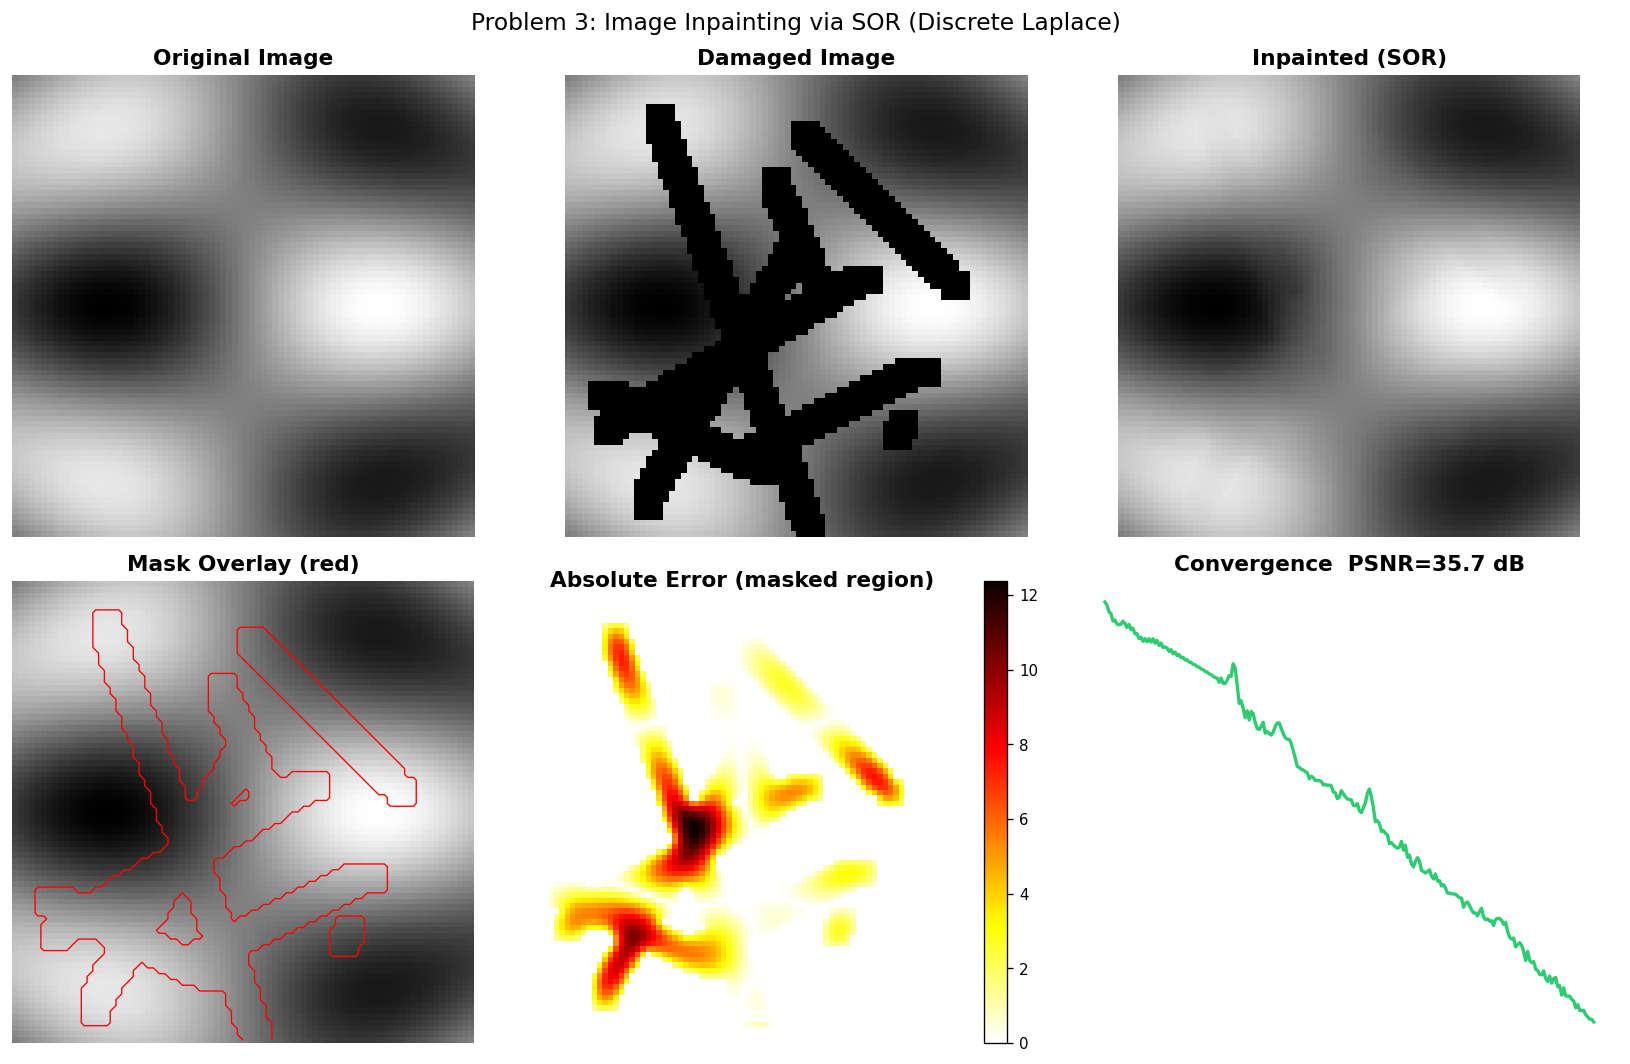

In [19]:
# ============================================================
# PROBLEM 3: Inpainting Visualisation
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(14, 9))

im_kw = dict(cmap='gray', vmin=0, vmax=255)

axes[0,0].imshow(img,       **im_kw); axes[0,0].set_title('Original Image',  fontweight='bold')
axes[0,1].imshow(damaged,   **im_kw); axes[0,1].set_title('Damaged Image',   fontweight='bold')
axes[0,2].imshow(inpainted, **im_kw); axes[0,2].set_title('Inpainted (SOR)', fontweight='bold')

# Mask overlay
axes[1,0].imshow(img, **im_kw)
axes[1,0].contour(mask, colors='red', linewidths=0.8)
axes[1,0].set_title('Mask Overlay (red)', fontweight='bold')

# Error map
err_map = np.abs(img - inpainted)
err_map[~mask] = 0   # show error only in inpainted region
im_err = axes[1,1].imshow(err_map, cmap='hot_r')
plt.colorbar(im_err, ax=axes[1,1])
axes[1,1].set_title('Absolute Error (masked region)', fontweight='bold')

# Convergence
axes[1,2].semilogy(hist_inp, color=COLORS['sor'])
axes[1,2].set_xlabel('Iteration')
axes[1,2].set_ylabel('Max change per iteration (log)')
axes[1,2].set_title(f'Convergence  PSNR={psnr:.1f} dB', fontweight='bold')

for ax in axes.flat:
    ax.axis('off') if ax in axes[:2,:].flat else None

plt.suptitle('Problem 3: Image Inpainting via SOR (Discrete Laplace)', fontsize=14)
plt.tight_layout()
plt.savefig('inpainting.png', bbox_inches='tight')
plt.show()


---
## 7b. SOR Scalability Analysis

We now empirically confirm how SOR's convergence rate scales with grid size $n$, and how choosing $\omega$ incorrectly vs optimally impacts performance.


In [20]:
# ============================================================
# SCALABILITY: SOR iteration counts vs grid size n
# ============================================================
ns_bench = [5, 8, 12, 16, 20, 30]
iters_sor_bench = []
omegas_bench    = []

for n_i in ns_bench:
    rho_jn = np.cos(np.pi / (n_i + 1))
    om_n   = 2 / (1 + np.sqrt(1 - rho_jn**2))
    rho_s  = om_n - 1
    omegas_bench.append(om_n)
    iters_sor_bench.append(int(np.ceil(-6*np.log(10)/np.log(max(rho_s, 1e-15)))))

print(f"{'Grid n':>8} | {'ω*':>8} | {'ρ(T_ω*)':>10} | {'SOR iters':>12}")
print("-" * 48)
for n_i, om, iters in zip(ns_bench, omegas_bench, iters_sor_bench):
    rho_s = om - 1
    print(f"{n_i:8d} | {om:8.4f} | {rho_s:10.6f} | {iters:12d}")


  Grid n |       ω* |    ρ(T_ω*) |    SOR iters
------------------------------------------------
       5 |   1.3333 |   0.333333 |           13
       8 |   1.4903 |   0.490291 |           20
      12 |   1.6138 |   0.613794 |           29
      16 |   1.6895 |   0.689547 |           38
      20 |   1.7406 |   0.740580 |           47
      30 |   1.8163 |   0.816253 |           69


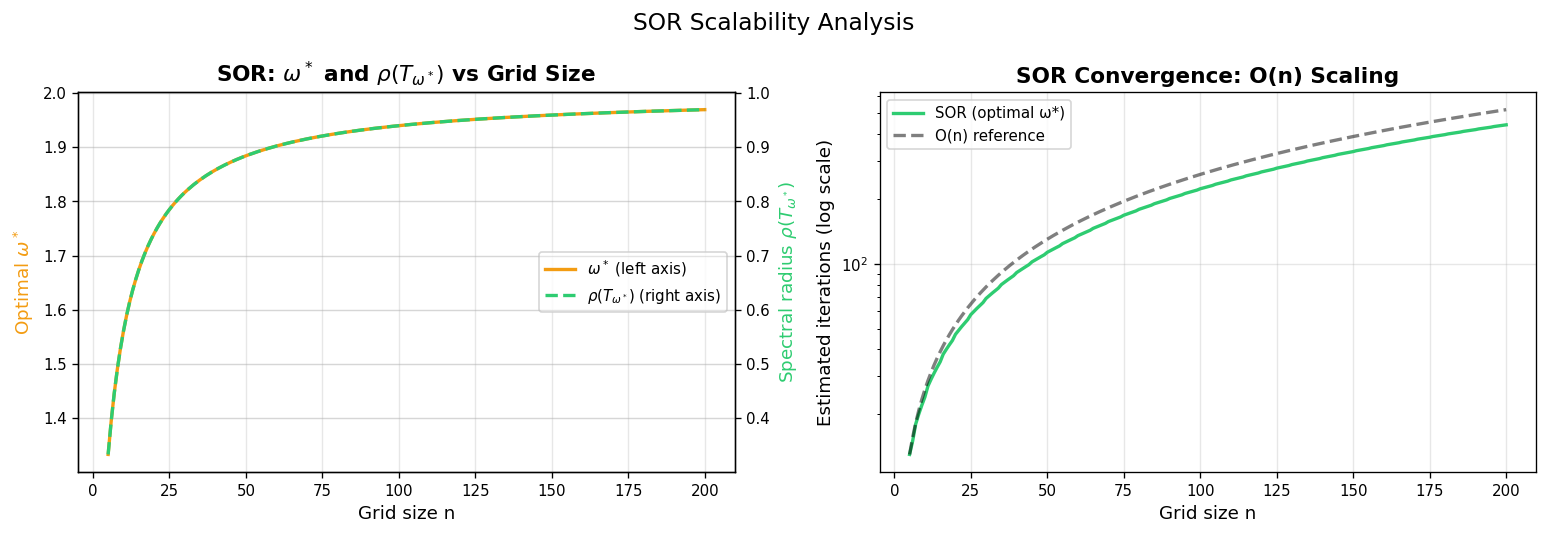

In [22]:
# ============================================================
# SOR SCALABILITY PLOT
# ============================================================
ns_theory = np.arange(5, 201)
rho_J_t   = np.cos(np.pi / (ns_theory + 1))
omega_t   = 2 / (1 + np.sqrt(1 - rho_J_t**2))
rho_SOR_t = omega_t - 1
iters_SOR_t = np.ceil(-6*np.log(10) / np.log(np.maximum(rho_SOR_t, 1e-15)))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: ω* and ρ(T_ω*) vs n
ax = axes[0]
ax2 = ax.twinx()
ax.plot(ns_theory, omega_t,   color='#F39C12', lw=2, label=r'$\omega^*$ (left axis)')
ax2.plot(ns_theory, rho_SOR_t, color='#2ECC71', lw=2, ls='--', label=r'$\rho(T_{\omega^*})$ (right axis)')
ax.set_xlabel('Grid size n'); ax.set_ylabel(r'Optimal $\omega^*$', color='#F39C12')
ax2.set_ylabel(r'Spectral radius $\rho(T_{\omega^*})$', color='#2ECC71')
ax.set_title(r'SOR: $\omega^*$ and $\rho(T_{\omega^*})$ vs Grid Size', fontweight='bold')
lines1, labs1 = ax.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labs1+labs2, loc='center right')

# Right: iteration count vs n (log scale)
ax = axes[1]
ax.semilogy(ns_theory, iters_SOR_t, color='#2ECC71', lw=2, label='SOR (optimal ω*)')
# O(n) reference line
c_ref = iters_SOR_t[0] / ns_theory[0]
ax.semilogy(ns_theory, c_ref * ns_theory, 'k--', alpha=0.5, label='O(n) reference')
ax.set_xlabel('Grid size n'); ax.set_ylabel('Estimated iterations (log scale)')
ax.set_title('SOR Convergence: O(n) Scaling', fontweight='bold')
ax.legend()

plt.suptitle('SOR Scalability Analysis', fontsize=14)
plt.tight_layout()
plt.savefig('sor_scalability.png', bbox_inches='tight')
plt.show()


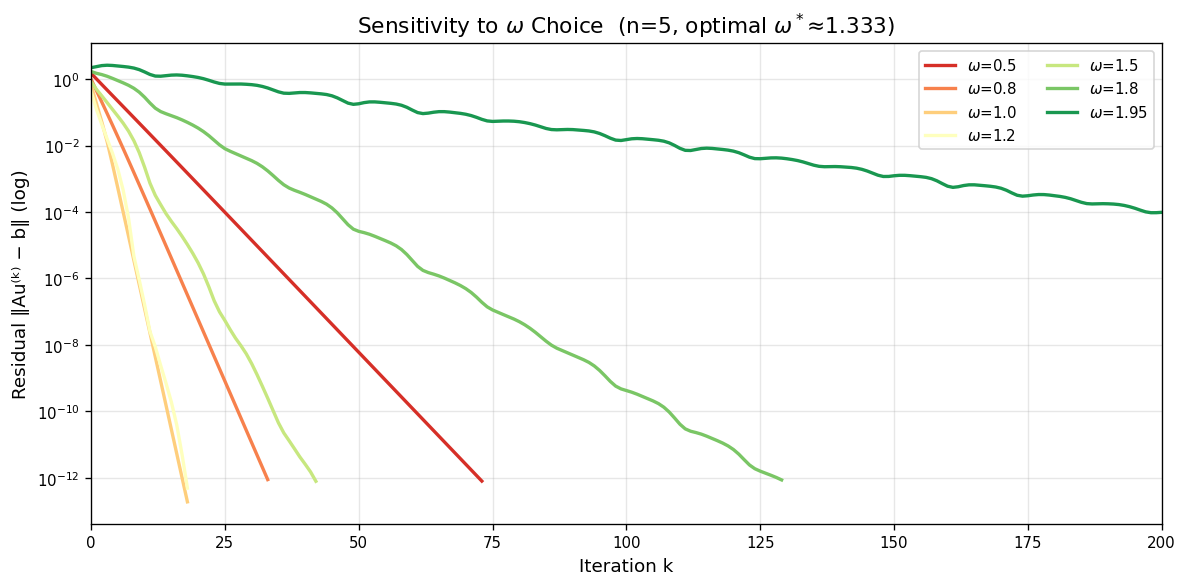

Optimal ω* = 1.3333

Summary of iteration counts:
     ω |   Iterations
----------------------
  0.50 |           74
  0.80 |           34
  1.00 |           19
  1.20 |           19
  1.50 |           43
  1.80 |          130
  1.95 |          559


In [24]:
# ============================================================
# EDA: Sensitivity of convergence to choice of omega
# ============================================================
n_test = 5
A_test = (np.diag(4*np.ones(n_test))
          + np.diag(-np.ones(n_test-1), k=1)
          + np.diag(-np.ones(n_test-1), k=-1))
b_test = np.ones(n_test)

omega_vals   = [0.5, 0.8, 1.0, 1.2, 1.5, 1.8, 1.95]
omega_colors = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(omega_vals)))

fig, ax = plt.subplots(figsize=(10, 5))

rho_j_t = np.cos(np.pi / (n_test + 1))
om_star_t = 2 / (1 + np.sqrt(1 - rho_j_t**2))

for om, col in zip(omega_vals, omega_colors):
    _, hist = sor_solver(A_test, b_test, omega=om, tol=1e-12, max_iter=2000)
    label = fr'$\omega$={om}' + (' ← optimal' if abs(om - om_star_t) < 0.05 else '')
    ax.semilogy(hist, color=col, lw=2, label=label)

ax.set_xlabel('Iteration k')
ax.set_ylabel('Residual ‖Au⁽ᵏ⁾ − b‖ (log)')
ax.set_title(fr'Sensitivity to $\omega$ Choice  (n=5, optimal $\omega^*≈{om_star_t:.3f}$)',
             fontsize=13)
ax.legend(loc='upper right', ncol=2)
ax.set_xlim(0, 200)

plt.tight_layout()
plt.savefig('omega_sensitivity.png', bbox_inches='tight')
plt.show()

print(f"Optimal ω* = {om_star_t:.4f}")
print("\nSummary of iteration counts:")
print(f"{'ω':>6} | {'Iterations':>12}")
print("-" * 22)
for om in omega_vals:
    _, hist = sor_solver(A_test, b_test, omega=om, tol=1e-12, max_iter=2000)
    print(f"{om:6.2f} | {len(hist):12d}")


---
## 8. Summary & Key Takeaways

### Mathematical Summary

| Concept | Formula | Key condition |
|---------|---------|---------------|
| Matrix splitting | $A = M - N$ | $M$ invertible, cheap to factor |
| Fixed-point iteration | $\mathbf{u}^{(k+1)} = T\mathbf{u}^{(k)} + \mathbf{c}$ | $T = M^{-1}N$ |
| Convergence criterion | $\rho(T) < 1$ | Spectral radius below 1 |
| SOR update | $u_i^{(k+1)} = (1-\omega)u_i^{(k)} + \omega\tilde{u}_i^{(k+1)}$ | $\omega \in (0,2)$ |
| SOR iteration matrix | $T_\omega = (D-\omega L)^{-1}[(1-\omega)D+\omega U]$ | |
| Kahan's necessary cond. | $\omega \in (0,2)$ | Hard boundary |
| Ostrowski-Reich | Converges ∀$\omega\in(0,2)$ if $A$ SPD | Guaranteed for Laplacian |
| Optimal $\omega^*$ | $2/(1+\sqrt{1-\rho_J^2})$ | Young (1954) |
| Optimal spectral radius | $\rho(T_{\omega^*}) = \omega^* - 1$ | — |

### SOR Convergence Rate

| Relaxation | Iterations (large n) | Notes |
|------------|---------------------|-------|
| $\omega < 1$ (under) | Slower than optimal | Stable for ill-conditioned problems |
| $\omega = 1$ (GS limit) | $O(n^2)$ | Baseline |
| **$\omega = \omega^*$ (optimal)** | **$O(n)$** | **Best possible for this family** |
| $\omega \geq 2$ | Diverges | Forbidden by Kahan's theorem |

### Practical Guidelines

1. **Always use $\omega \in (0,2)$** — outside this range, SOR cannot converge (Kahan).
2. **Compute $\omega^*$ using Young's formula** when the problem structure is known.
3. **When grid structure is unknown**, use $\omega \approx 1.7$–$1.9$ as a practical default.
4. **For non-SPD systems**, verify convergence empirically or use $\omega < 1$ for stability.
5. **Red-black (checkerboard) ordering** enables vectorised/parallel SOR with no sequential dependency.

### Applications

- **PDEs**: Laplace, Poisson, heat equation — any problem yielding a sparse SPD system
- **Image processing**: Inpainting, denoising, super-resolution
- **Structural mechanics**: Finite-element stiffness systems
- **Computational fluid dynamics**: Pressure-correction equations
- **Circuit simulation**: Nodal analysis

---

### References

1. Young, D.M. (1954). *Iterative methods for solving partial difference equations of elliptic type.* Trans. Amer. Math. Soc., 76, 92–111.
2. Kahan, W. (1958). *Gauss-Seidel methods of solving large systems of linear equations.* PhD thesis, University of Toronto.
3. Ostrowski, A.M. (1954). *On the linear iteration procedures for symmetric matrices.* Rend. Mat. Appl., 14, 140–163.
4. Saad, Y. (2003). *Iterative Methods for Sparse Linear Systems.* SIAM.
5. Golub, G.H. & Van Loan, C.F. (2013). *Matrix Computations* (4th ed.). Johns Hopkins.


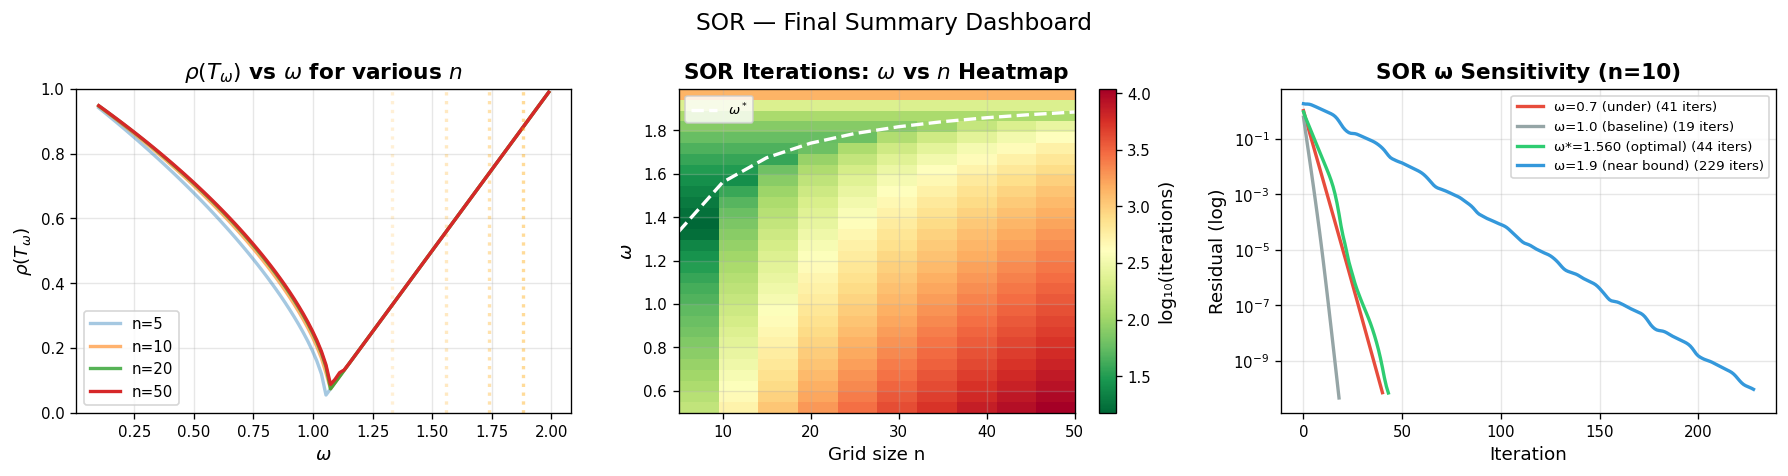


 Final Summary Dashboard 


In [27]:
# ============================================================
# FINAL SUMMARY FIGURE — SOR focused
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. ρ(T_ω) vs ω for multiple grid sizes
ax = axes[0]
for n_i, alpha in [(5,0.4),(10,0.6),(20,0.8),(50,1.0)]:
    A_i = np.diag(4*np.ones(n_i)) + np.diag(-np.ones(n_i-1),1) + np.diag(-np.ones(n_i-1),-1)
    oms_i  = np.linspace(0.1, 1.99, 100)
    rhos_i = [spectral_radius(build_iteration_matrices(A_i, w)[2]) for w in oms_i]
    om_star_i = 2/(1+np.sqrt(1-np.cos(np.pi/(n_i+1))**2))
    ax.plot(oms_i, rhos_i, alpha=alpha, label=f'n={n_i}')
    ax.axvline(om_star_i, alpha=alpha*0.4, color='orange', ls=':')
ax.set_xlabel(r'$\omega$'); ax.set_ylabel(r'$\rho(T_\omega)$')
ax.set_title(r'$\rho(T_\omega)$ vs $\omega$ for various $n$', fontweight='bold')
ax.legend(); ax.set_ylim(0,1)

# 2. Iteration count heat map: omega vs n
ax = axes[1]
ns_hm    = np.arange(5, 51, 5)
oms_hm   = np.linspace(0.5, 1.99, 30)
iter_map = np.zeros((len(oms_hm), len(ns_hm)))

for j, n_i in enumerate(ns_hm):
    A_i = np.diag(2*np.ones(n_i)) + np.diag(-np.ones(n_i-1),1) + np.diag(-np.ones(n_i-1),-1)
    for i, om in enumerate(oms_hm):
        _, _, T_om = build_iteration_matrices(A_i, om)
        rho_om = spectral_radius(T_om)
        iter_map[i,j] = -6*np.log(10)/np.log(rho_om) if rho_om < 1 else 1e5

im = ax.imshow(np.log10(iter_map+1), aspect='auto', origin='lower',
               extent=[ns_hm[0], ns_hm[-1], oms_hm[0], oms_hm[-1]],
               cmap='RdYlGn_r')
plt.colorbar(im, ax=ax, label='log₁₀(iterations)')
om_star_line = 2/(1 + np.sqrt(1 - np.cos(np.pi/(ns_hm+1))**2))
ax.plot(ns_hm, om_star_line, 'w--', lw=2, label=r'$\omega^*$')
ax.set_xlabel('Grid size n'); ax.set_ylabel(r'$\omega$')
ax.set_title(r'SOR Iterations: $\omega$ vs $n$ Heatmap', fontweight='bold')
ax.legend(fontsize=8)

# 3. ω sensitivity for a fixed n
ax = axes[2]
n_c = 10
rho_jc = np.cos(np.pi/(n_c+1))
om_c   = 2/(1+np.sqrt(1-rho_jc**2))
A_c = np.diag(4*np.ones(n_c)) + np.diag(-np.ones(n_c-1),1) + np.diag(-np.ones(n_c-1),-1)
b_c = np.random.default_rng(0).random(n_c)

for om, col, lbl in [(0.7,'#E74C3C','ω=0.7 (under)'),
                      (1.0,'#95A5A6','ω=1.0 (baseline)'),
                      (om_c,'#2ECC71',f'ω*={om_c:.3f} (optimal)'),
                      (1.9,'#3498DB','ω=1.9 (near bound)')]:
    _, h = sor_solver(A_c, b_c, omega=om, tol=1e-10, max_iter=3000)
    ax.semilogy(h, color=col, label=f'{lbl} ({len(h)} iters)')

ax.set_xlabel('Iteration'); ax.set_ylabel('Residual (log)')
ax.set_title(f'SOR ω Sensitivity (n={n_c})', fontweight='bold')
ax.legend(fontsize=8)

plt.suptitle('SOR — Final Summary Dashboard', fontsize=14)
plt.tight_layout()
plt.savefig('summary_dashboard.png', bbox_inches='tight')
plt.show()

print('\n' + '='*60)
print(' Final Summary Dashboard ')
print('='*60)
